This project uses Monte Carlo simulation to estimate Original Oil in Place (OOIP) under uncertainty.

Uncertain reservoir parameters such as thickness, porosity, and water saturation are modeled using probability distributions to generate a range of possible outcomes.

In [1]:
import numpy as np # to generate random values based on distribution
import pandas as pd # to generate table based on random values
import matplotlib.pyplot as plt

In [2]:
area = 5000  # acres
boi = 1.1    # rb/stb
cases = 100000

In [3]:
uncertain_h = np.random.normal(loc=45, scale=3, size=cases) # loc = mean, scale = stddev
uncertain_phi = np.random.triangular(left=0.1, mode=0.2, right=0.35, size=cases) # left = min, mode = most likely, right = max
uncertain_sw = np.random.uniform(low=0.15, high=0.45, size=cases) # uniform distribution between 0.15 and 0.45

Different probability distributions are used to represent uncertainty:
- Thickness → Normal distribution  
- Porosity → Triangular distribution  
- Water saturation → Uniform distribution  

In [ ]:
# how to generte a table
# 1 - create a dictionary
data = dict(h=uncertain_h, phi=uncertain_phi, sw=uncertain_sw)
# 2 - create a dataframe
sim_data = pd.DataFrame(data)
reserve = 7758 * area * sim_data['h'] * sim_data['phi'] * (1 - sim_data['sw'])/boi
sim_data['ooip_stb'] = reserve
sim_data
# export to csv
sim_data.to_csv('monte_carlo_simulation_results.csv')


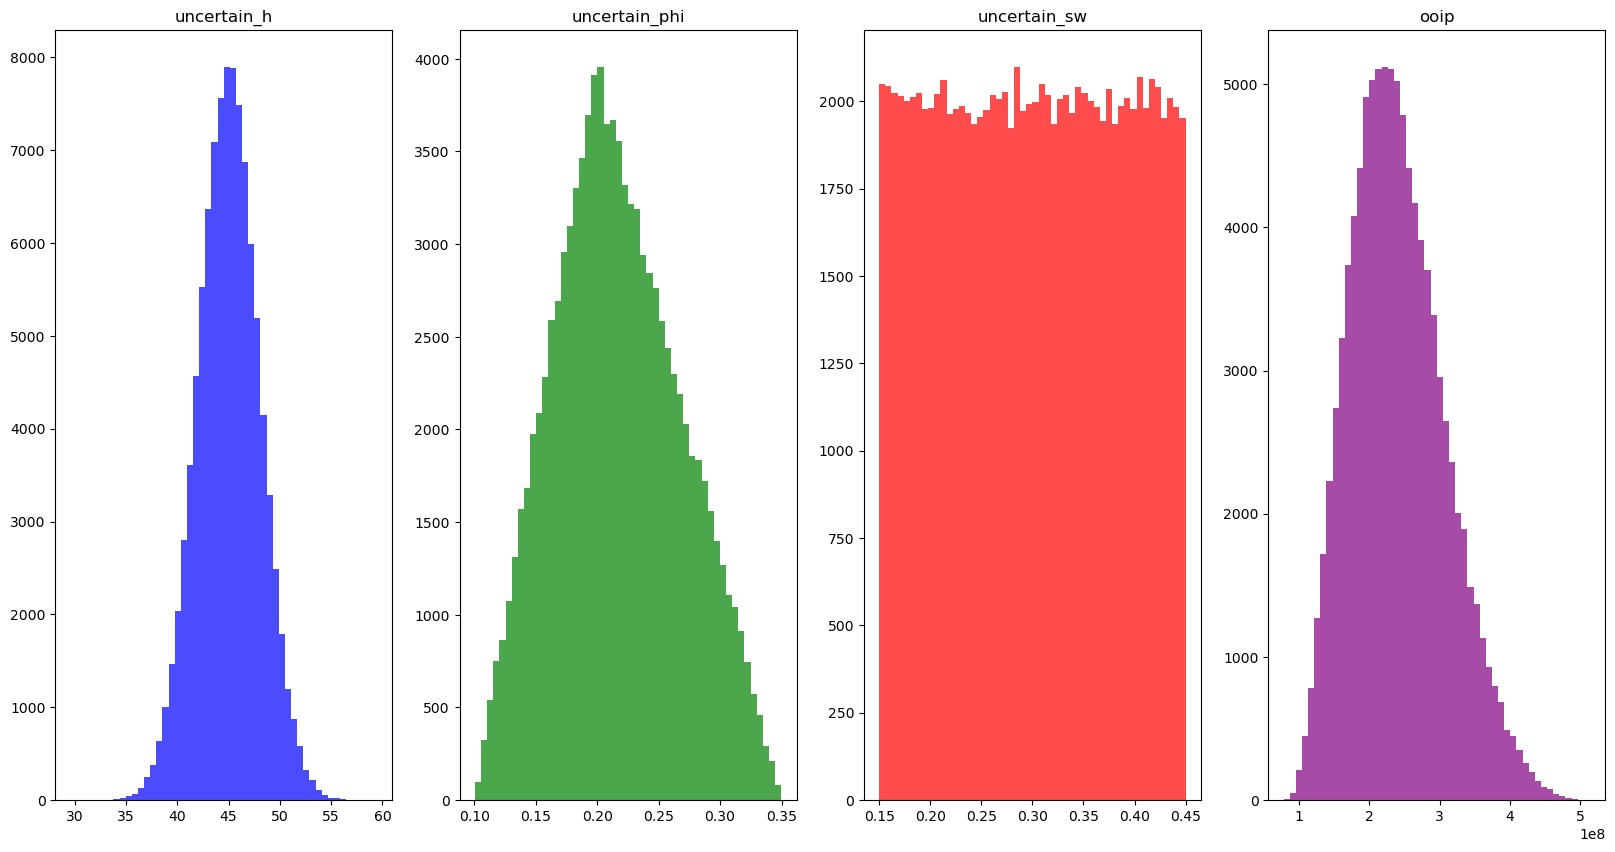

In [ ]:
# histogram (create the plot or subplot)
fig, ax = plt.subplots(ncols=4, figsize=(20,10))
ax[0].hist(sim_data['h'], bins=50, color='blue', alpha=0.7) 
ax[0].set_title('uncertain_h')

ax[1].hist(sim_data['phi'], bins=50, color='green', alpha=0.7)
ax[1].set_title('uncertain_phi')

ax[2].hist(sim_data['sw'], bins=50, color='red', alpha=0.7)
ax[2].set_title('uncertain_sw')

ax[3].hist(sim_data['ooip_stb'], bins=50, color='purple', alpha=0.7)
ax[3].set_title('ooip_stb')

plt.savefig('../images/monte_carlo_simulation_histograms.png')
plt.show()

In [6]:
p10 = np.percentile(sim_data['ooip'], 10)
p50 = np.percentile(sim_data['ooip'], 50)
p90 = np.percentile(sim_data['ooip'], 90)

print("P10:", p10)
print("P50:", p50)
print("P90:", p90)

P10: 157971736.86587992
P50: 234494979.86842176
P90: 332575317.653511


P10, P50, and P90 values provide a probabilistic range of OOIP estimates:
- P10 → Conservative estimate  
- P50 → Most likely estimate  
- P90 → Optimistic estimate  

- Monte Carlo simulation captures uncertainty in reservoir parameters  
- OOIP is highly sensitive to porosity and water saturation  
- The resulting distribution provides a probabilistic range instead of a single estimate  
- P10–P90 values support risk-based decision making  

This project demonstrates how probabilistic methods can be applied to reservoir evaluation to improve decision-making under uncertainty.

Monte Carlo simulation is widely used in reservoir engineering for reserves estimation and risk analysis.